# TP N°5: Normalisation et Balancing

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("../tp_3n4/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1. la différence entre normalisation et standardisation


la normalisation transforme les données dans un intervalle [0,1] en utilisant la formule de min max or la nouvelle valeur de X' et
X-Xmin/Xmax-Xmin.
la standardisation centre les données autour de 0 avec écart-type 1 en utlisant la formule de z-core où z = X- le moyenne / l'écart-type.

### 2. Pourquoi est-il important de normaliser ou standardiser les données avant d’appliquer certains modèles?

certains modèles sont sensibles à l’échelle comme KNN, K-Means, SVM, Régression logistique, Réseaux de neurones et PCA
sans scaling fare peut aller jusqu’à 500+
age entre 0 et 80
donc Fare domine le modèle.
la normalisation évite ça.

### 3. Application

In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

cols = ["Age", "Fare"]

minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[cols] = minmax.fit_transform(df[cols])

print("min-max scaling")
print(df_minmax[cols].head())

scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[cols] = scaler.fit_transform(df[cols])

print("z-score scaling")
print(df_zscore[cols].head())

min-max scaling
        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713
z-score scaling
        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


### 4. Oversampling vs Undersampling

l’oversampling ajoute des données à la classe minoritaire, tandis que l’undersampling retire des données de la classe majoritaire. Le choix entre les deux dépend surtout de la taille du dataset : pour un petit dataset, l’oversampling est souvent préférable, alors que pour un très grand dataset, l’undersampling peut être une bonne solution.

### 5. Techniques d'équilibrage d'un ensemble de données

1. **Random oversampling** consiste à augmenter la classe minoritaire en dupliquant aléatoirement des exemples existants jusqu’à atteindre le même nombre que la classe majoritaire. aucune donnée n’est perdue / risque d’overfitting à cause des doublons
2. **Random undersampling** supprime aléatoirement des exemples de la classe majoritaire pour la ramener au niveau de la classe minoritaire. rapide et efficace / perte possible d’informations importantes
3. **SMOTE (Synthetic Minority Over-sampling Technique)** génère de nouveaux exemples synthétiques de la classe minoritaire à partir des voisins proches. moins d’overfitting que Random Oversampling / peut créer du bruit si les données sont mal distribuées

### 6. Application

In [26]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

data = df[["Survived", "Pclass", "Age", "Fare"]].copy()

x = data[["Pclass", "Age", "Fare"]]
y = data["Survived"]

print("avant équilibrage:")
print(y.value_counts())

under = RandomUnderSampler(random_state=42)
x_under, y_under = under.fit_resample(x, y)

print("\naprès undersampling:")
print(y_under.value_counts())

over = RandomOverSampler(random_state=42)
x_over, y_over = over.fit_resample(x, y)

print("\naprès oversampling:")
print(y_over.value_counts())

smote = SMOTE(random_state=42)
x_smote, y_smote = smote.fit_resample(x, y)

print("\naprès SMOTE:")
print(y_smote.value_counts())

avant équilibrage:
Survived
0    549
1    342
Name: count, dtype: int64

après undersampling:
Survived
0    342
1    342
Name: count, dtype: int64

après oversampling:
Survived
0    549
1    549
Name: count, dtype: int64

après SMOTE:
Survived
0    549
1    549
Name: count, dtype: int64


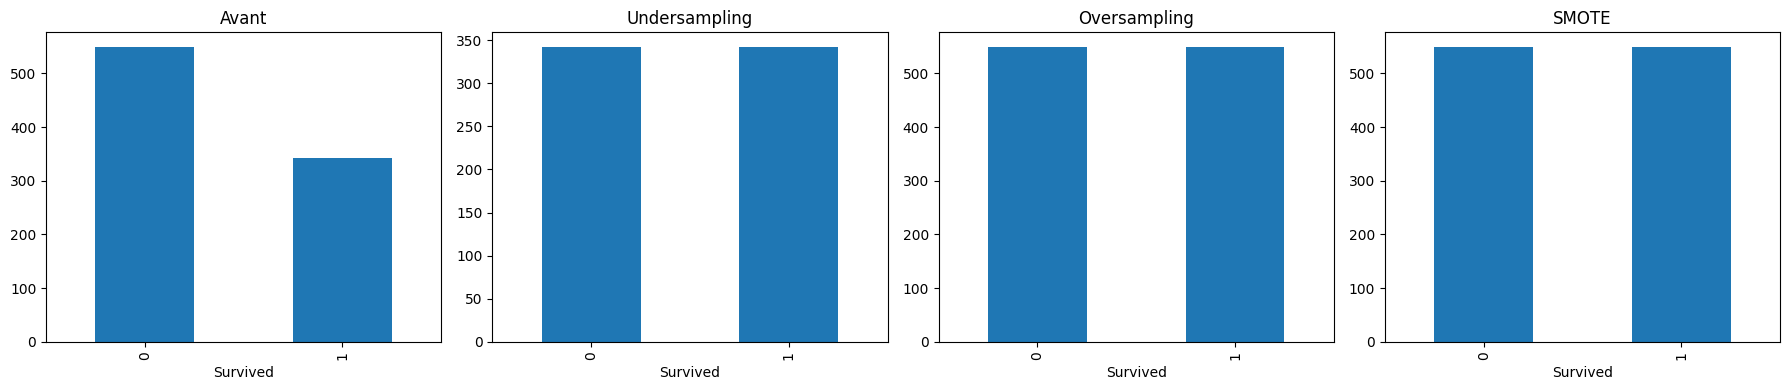

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

y.value_counts().plot(kind="bar", ax=axes[0], title="Avant")

y_under.value_counts().plot(kind="bar", ax=axes[1], title="Undersampling")

y_over.value_counts().plot(kind="bar", ax=axes[2], title="Oversampling")

y_smote.value_counts().plot(kind="bar", ax=axes[3], title="SMOTE")

plt.tight_layout()
plt.show()